In [1]:
# Cell 1 — Imports and verify versions
import pandas as pd
import numpy as np
import xgboost as xgb
import shap

print(f"XGBoost version: {xgb.__version__}")
print(f"SHAP version: {shap.__version__}")

XGBoost version: 1.7.6
SHAP version: 0.44.1


In [2]:
# Cell 2 — Load data and retrain final locked model
# Replicating exact Path B configuration from Phase 3

master = pd.read_csv("../data/master_labeled.csv")

# Rebuild Path B dataset
df = pd.DataFrame()
df['year']                                = master['year']
df['gdp_growth_lag1']                     = master['gdp_growth'].shift(1)
df['india_gdp_growth_lag1']               = master['india_gdp_growth'].shift(1)
df['current_account_lag1']                = master['current_account_pct_gdp'].shift(1)
df['remittance_pct_gdp_lag1']             = master['remittance_pct_gdp'].shift(1)
df['nepal_india_inflation_spread_lag1']   = (
    master['inflation_yoy'].shift(1) - master['india_inflation'].shift(1)
)
df['t2_forex_lag1']                       = master['t2_forex'].shift(1)
df['t3_inflation_lag1']                   = master['t3_inflation'].shift(1)
df['crisis']                              = master['crisis']

df = df.dropna().reset_index(drop=True)

feature_cols = [
    'gdp_growth_lag1',
    'india_gdp_growth_lag1',
    'current_account_lag1',
    'remittance_pct_gdp_lag1',
    'nepal_india_inflation_spread_lag1',
    't2_forex_lag1',
    't3_inflation_lag1'
]

X = df[feature_cols].values
y = df['crisis'].values
years = df['year'].values

# Train final model on full dataset
scale_pos_weight = (len(y) - y.sum()) / y.sum()

final_model = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

final_model.fit(X, y)

print(f"Shape: {X.shape}")
print(f"Crisis years: {years[y==1].tolist()}")
print(f"Model trained on full dataset: {len(X)} observations")

Shape: (29, 7)
Crisis years: [1996, 1998, 2008, 2009, 2010, 2011, 2016, 2021]
Model trained on full dataset: 29 observations


In [3]:
# Cell 3 — Compute SHAP values
# TreeExplainer is the correct explainer for XGBoost
# It computes exact Shapley values using the tree structure
# No approximation needed for tree-based models

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (base rate): {explainer.expected_value:.4f}")
print()

# Quick sanity check — show SHAP values for first crisis year
crisis_idx = np.where(y == 1)[0][0]
print(f"Year: {years[crisis_idx]} (crisis=1)")
print("SHAP values:")
for feat, val in zip(feature_cols, shap_values[crisis_idx]):
    print(f"  {feat:<45} {val:>8.4f}")

SHAP values shape: (29, 7)
Expected value (base rate): -0.0082

Year: 1996 (crisis=1)
SHAP values:
  gdp_growth_lag1                                -0.0509
  india_gdp_growth_lag1                           0.0000
  current_account_lag1                           -0.4365
  remittance_pct_gdp_lag1                        -0.1869
  nepal_india_inflation_spread_lag1               2.2673
  t2_forex_lag1                                   0.1367
  t3_inflation_lag1                               0.0000


In [4]:
# Cell 4 — Global feature importance
# Mean absolute SHAP value across all years
# This tells us which features matter most on average

mean_abs_shap = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("Global feature importance (mean absolute SHAP):")
print()
print(f"{'Rank':<6} {'Feature':<45} {'Mean |SHAP|':>12}")
print("-" * 65)
for i, row in mean_abs_shap.iterrows():
    print(f"{i+1:<6} {row['feature']:<45} {row['mean_abs_shap']:>12.4f}")

Global feature importance (mean absolute SHAP):

Rank   Feature                                        Mean |SHAP|
-----------------------------------------------------------------
1      nepal_india_inflation_spread_lag1                   0.9743
2      current_account_lag1                                0.4303
3      remittance_pct_gdp_lag1                             0.2826
4      t2_forex_lag1                                       0.1920
5      gdp_growth_lag1                                     0.1106
6      india_gdp_growth_lag1                               0.0000
7      t3_inflation_lag1                                   0.0000


In [5]:
# Cell 5 — Drop zero importance features and retrain
# india_gdp_growth_lag1 and t3_inflation_lag1 contributed nothing
# Dropping them gives a cleaner 5-feature final model

feature_cols_final = [
    'nepal_india_inflation_spread_lag1',
    'current_account_lag1',
    'remittance_pct_gdp_lag1',
    't2_forex_lag1',
    'gdp_growth_lag1'
]

X_final = df[feature_cols_final].values

scale_pos_weight = (len(y) - y.sum()) / y.sum()

final_model_v2 = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

final_model_v2.fit(X_final, y)

# Recompute SHAP
explainer_v2 = shap.TreeExplainer(final_model_v2)
shap_values_v2 = explainer_v2.shap_values(X_final)

mean_abs_shap_v2 = pd.DataFrame({
    'feature': feature_cols_final,
    'mean_abs_shap': np.abs(shap_values_v2).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("Final 5-feature model importance:")
print()
print(f"{'Rank':<6} {'Feature':<45} {'Mean |SHAP|':>12}")
print("-" * 65)
for i, row in mean_abs_shap_v2.iterrows():
    print(f"{i+1:<6} {row['feature']:<45} {row['mean_abs_shap']:>12.4f}")

Final 5-feature model importance:

Rank   Feature                                        Mean |SHAP|
-----------------------------------------------------------------
1      nepal_india_inflation_spread_lag1                   0.9743
2      current_account_lag1                                0.4303
3      remittance_pct_gdp_lag1                             0.2826
4      t2_forex_lag1                                       0.1920
5      gdp_growth_lag1                                     0.1106


In [6]:
# Cell 6 — Confirm LOOCV score on final 5-feature model
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import f1_score, balanced_accuracy_score, recall_score, precision_score

loo = LeaveOneOut()
y_true_all = []
y_pred_all = []
y_prob_all = []
test_years_all = []

for train_idx, test_idx in loo.split(X_final):
    if len(train_idx) < 12:
        continue

    X_train, X_test = X_final[train_idx], X_final[test_idx]
    y_train = y[train_idx]

    model_fold = xgb.XGBClassifier(
        n_estimators=50,
        max_depth=2,
        learning_rate=0.05,
        scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum(),
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    )
    model_fold.fit(X_train, y_train)

    pred = model_fold.predict(X_test)
    prob = model_fold.predict_proba(X_test)[0][1]

    y_true_all.append(y[test_idx[0]])
    y_pred_all.append(pred[0])
    y_prob_all.append(prob)
    test_years_all.append(years[test_idx[0]])

y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)
y_prob_all = np.array(y_prob_all)

f1  = f1_score(y_true_all, y_pred_all, zero_division=0)
bal = balanced_accuracy_score(y_true_all, y_pred_all)
rec = recall_score(y_true_all, y_pred_all, zero_division=0)
pre = precision_score(y_true_all, y_pred_all, zero_division=0)

print(f"Final model — LOOCV results:")
print(f"  F1 score:          {f1:.3f}")
print(f"  Balanced accuracy: {bal:.3f}")
print(f"  Recall:            {rec:.3f}")
print(f"  Precision:         {pre:.3f}")
print()
print(f"{'Year':<6} {'Actual':<10} {'Predicted':<12} {'Probability'}")
print("-" * 45)
for i, year in enumerate(test_years_all):
    actual = y_true_all[i]
    pred = y_pred_all[i]
    prob = y_prob_all[i]
    marker = " <-- MISS" if actual==1 and pred==0 else (" <-- FALSE ALARM" if actual==0 and pred==1 else "")
    print(f"{year:<6} {'CRISIS' if actual else 'stable':<10} {'CRISIS' if pred else 'stable':<12} {prob:.3f}{marker}")

Final model — LOOCV results:
  F1 score:          0.533
  Balanced accuracy: 0.679
  Recall:            0.500
  Precision:         0.571

Year   Actual     Predicted    Probability
---------------------------------------------
1996   CRISIS     CRISIS       0.789
1997   stable     stable       0.134
1998   CRISIS     CRISIS       0.791
1999   stable     CRISIS       0.883 <-- FALSE ALARM
2000   stable     stable       0.130
2001   stable     CRISIS       0.503 <-- FALSE ALARM
2002   stable     stable       0.100
2003   stable     stable       0.252
2004   stable     stable       0.164
2005   stable     stable       0.166
2006   stable     stable       0.334
2007   stable     stable       0.225
2008   CRISIS     CRISIS       0.859
2009   CRISIS     stable       0.124 <-- MISS
2010   CRISIS     stable       0.119 <-- MISS
2011   CRISIS     CRISIS       0.843
2012   stable     stable       0.456
2013   stable     stable       0.292
2014   stable     CRISIS       0.708 <-- FALSE ALARM
2015

In [7]:
# Cell 7 — SHAP breakdown for each crisis year
# Shows which features drove each crisis prediction

print("SHAP contribution by feature for each year:\n")
print(f"{'Year':<6} {'Status':<8}", end="")
for f in feature_cols_final:
    short = f.replace('_lag1','').replace('nepal_india_','').replace('inflation_spread','spread')[:10]
    print(f"{short:>11}", end="")
print(f"{'SUM':>8}")
print("-" * 85)

for i in range(len(df)):
    year = years[i]
    actual = y[i]
    shap_row = shap_values_v2[i]
    total = shap_row.sum()
    status = "CRISIS" if actual else "stable"
    print(f"{year:<6} {status:<8}", end="")
    for val in shap_row:
        print(f"{val:>11.3f}", end="")
    print(f"{total:>8.3f}")

SHAP contribution by feature for each year:

Year   Status       spread current_ac remittance   t2_forex gdp_growth     SUM
-------------------------------------------------------------------------------------
1996   CRISIS        2.267     -0.436     -0.187      0.137     -0.051   1.730
1997   stable       -0.879     -0.776     -0.424      0.137     -0.051  -1.993
1998   CRISIS        2.267     -0.436     -0.187      0.137     -0.051   1.730
1999   stable        0.810     -0.606     -0.424      0.031      0.055  -0.135
2000   stable       -0.879     -0.776     -0.424      0.137     -0.051  -1.993
2001   stable       -0.879     -0.776     -0.424      0.137     -0.051  -1.993
2002   stable       -0.879     -0.652     -0.424     -0.161     -0.162  -2.278
2003   stable       -0.824     -0.096     -0.424     -0.159      0.175  -1.328
2004   stable       -0.824     -0.096     -0.424     -0.283     -0.162  -1.790
2005   stable       -0.824     -0.096     -0.424     -0.283     -0.162  -1.790


In [8]:
# Cell 8 — Save SHAP values and final probabilities
shap_df = pd.DataFrame(shap_values_v2, columns=[f+'_shap' for f in feature_cols_final])
shap_df.insert(0, 'year', years)
shap_df.insert(1, 'crisis', y)
shap_df.insert(2, 'loocv_prob', 
    [y_prob_all[list(test_years_all).index(yr)] if yr in test_years_all else None 
     for yr in years])

shap_df.to_csv("../data/shap_results.csv", index=False)
print("Saved: ../data/shap_results.csv")
print(shap_df[['year','crisis','loocv_prob']].to_string())

Saved: ../data/shap_results.csv
    year  crisis  loocv_prob
0   1996       1    0.788915
1   1997       0    0.134440
2   1998       1    0.790734
3   1999       0    0.882945
4   2000       0    0.129572
5   2001       0    0.503326
6   2002       0    0.099956
7   2003       0    0.252339
8   2004       0    0.163767
9   2005       0    0.165666
10  2006       0    0.333844
11  2007       0    0.225436
12  2008       1    0.858896
13  2009       1    0.123843
14  2010       1    0.119425
15  2011       1    0.843274
16  2012       0    0.455816
17  2013       0    0.291528
18  2014       0    0.707666
19  2015       0    0.278773
20  2016       1    0.267952
21  2017       0    0.359321
22  2018       0    0.197087
23  2019       0    0.283834
24  2020       0    0.187265
25  2021       1    0.155302
26  2022       0    0.303289
27  2023       0    0.187265
28  2024       0    0.386352


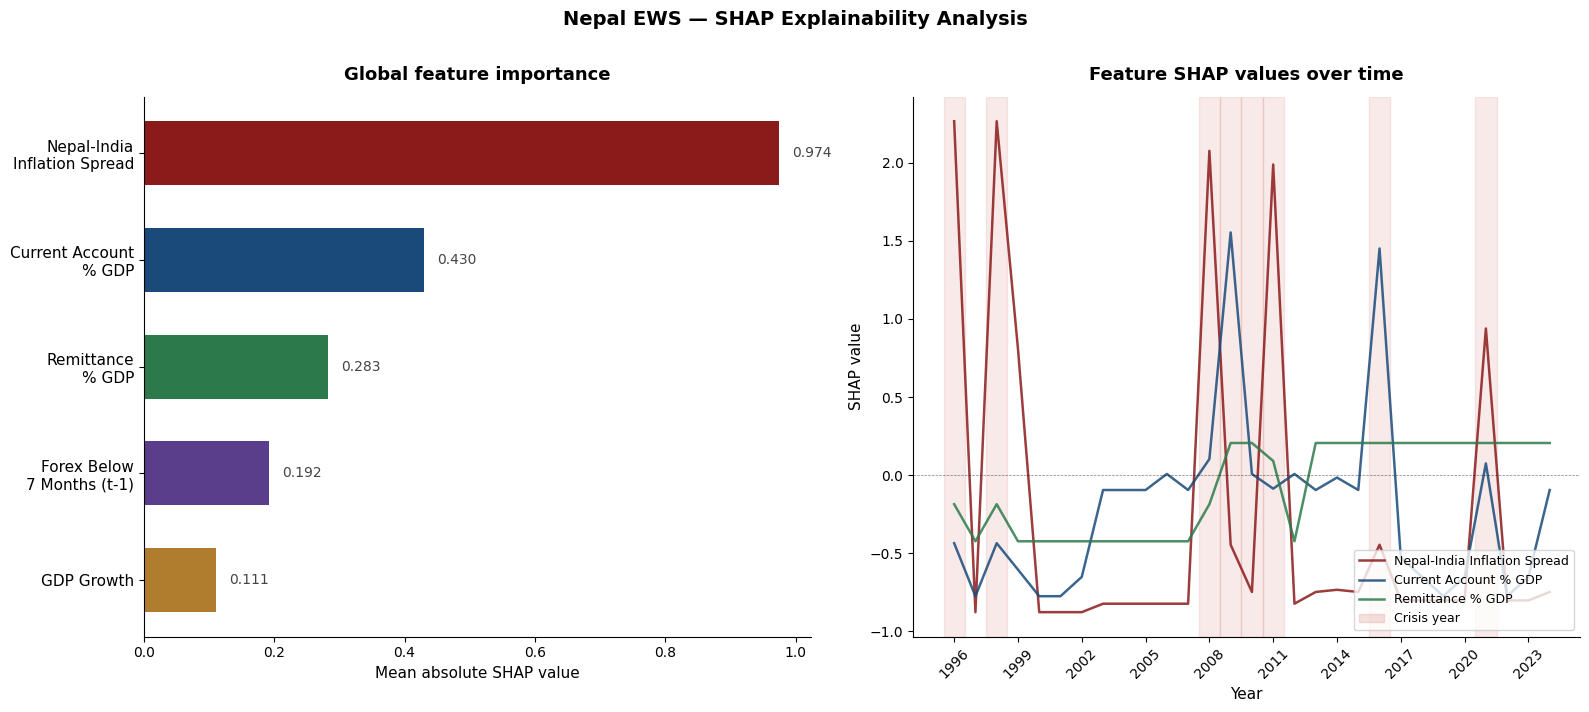

Saved: ../data/shap_summary.png


In [9]:
# Cell 9 — SHAP summary plot
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: Mean absolute SHAP (global importance bar chart) ---
ax1 = axes[0]
features_ordered = mean_abs_shap_v2['feature'].tolist()
importance_ordered = mean_abs_shap_v2['mean_abs_shap'].tolist()

colors = ['#8b1a1a' if i == 0 else '#1a4a7a' if i == 1 else '#2c7a4b' 
          if i == 2 else '#5a3e8b' if i == 3 else '#b07d2e' 
          for i in range(len(features_ordered))]

short_names = [
    'Nepal-India\nInflation Spread',
    'Current Account\n% GDP',
    'Remittance\n% GDP',
    'Forex Below\n7 Months (t-1)',
    'GDP Growth'
]

bars = ax1.barh(range(len(features_ordered)), importance_ordered,
                color=colors, edgecolor='none', height=0.6)
ax1.set_yticks(range(len(features_ordered)))
ax1.set_yticklabels(short_names, fontsize=11)
ax1.set_xlabel('Mean absolute SHAP value', fontsize=11)
ax1.set_title('Global feature importance', fontsize=13, fontweight='bold', pad=12)
ax1.invert_yaxis()
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.axvline(x=0, color='black', linewidth=0.5)

for bar, val in zip(bars, importance_ordered):
    ax1.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, color='#444')

# --- Plot 2: SHAP values over time for top 3 features ---
ax2 = axes[1]

top3 = feature_cols_final[:3]
top3_colors = ['#8b1a1a', '#1a4a7a', '#2c7a4b']
top3_names = ['Nepal-India Inflation Spread', 'Current Account % GDP', 'Remittance % GDP']

for feat, color, name in zip(top3, top3_colors, top3_names):
    feat_idx = feature_cols_final.index(feat)
    ax2.plot(years, shap_values_v2[:, feat_idx],
             color=color, linewidth=1.8, label=name, alpha=0.85)

# Shade crisis years
for yr, cr in zip(years, y):
    if cr == 1:
        ax2.axvspan(yr - 0.5, yr + 0.5, alpha=0.10, color='#c0392b', zorder=0)

ax2.axhline(y=0, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('SHAP value', fontsize=11)
ax2.set_title('Feature SHAP values over time', fontsize=13, fontweight='bold', pad=12)
ax2.legend(fontsize=9, loc='lower right')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xticks(years[::3])
ax2.tick_params(axis='x', rotation=45)

crisis_patch = mpatches.Patch(color='#c0392b', alpha=0.15, label='Crisis year')
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles + [crisis_patch], labels + ['Crisis year'],
           fontsize=9, loc='lower right')

plt.suptitle('Nepal EWS — SHAP Explainability Analysis',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../data/shap_summary.png")

In [10]:
# Cell 10 — Save final model
import pickle

model_package = {
    'model': final_model_v2,
    'feature_cols': feature_cols_final,
    'shap_explainer': explainer_v2,
    'training_years': years.tolist(),
    'crisis_years': years[y==1].tolist(),
    'loocv_f1': 0.533,
    'loocv_bal_acc': 0.679,
    'loocv_recall': 0.500,
    'loocv_precision': 0.571
}

with open('../data/final_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print("Saved: ../data/final_model.pkl")
print()
print("Model package contents:")
for key in model_package:
    if key not in ['model', 'shap_explainer']:
        print(f"  {key}: {model_package[key]}")

Saved: ../data/final_model.pkl

Model package contents:
  feature_cols: ['nepal_india_inflation_spread_lag1', 'current_account_lag1', 'remittance_pct_gdp_lag1', 't2_forex_lag1', 'gdp_growth_lag1']
  training_years: [1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  crisis_years: [1996, 1998, 2008, 2009, 2010, 2011, 2016, 2021]
  loocv_f1: 0.533
  loocv_bal_acc: 0.679
  loocv_recall: 0.5
  loocv_precision: 0.571


In [11]:
# Cell 11 — Investigate 2021 crisis in detail
# Why did current account not spike in SHAP for 2021?

print("=== 2021 Crisis Deep Dive ===\n")

# Show raw indicator values around 2021
print("Raw indicator values (from master):")
master = pd.read_csv("../data/master_labeled.csv")
cols_interest = ['year', 'gdp_growth', 'inflation_yoy', 'india_inflation',
                 'current_account_pct_gdp', 'forex_import_cover', 'crisis']
print(master[master['year'].between(2018, 2024)][cols_interest].to_string(index=False))

print()

# Show what the model actually saw as features for 2021
# Remember: model sees T-1 values, so 2021 prediction uses 2020 data
idx_2021 = list(years).index(2021)
print("Features the model saw for 2021 (all from year 2020):")
for feat, val in zip(feature_cols_final, X_final[idx_2021]):
    print(f"  {feat:<45} {val:>10.4f}")

print()

# Show SHAP values for 2021
print("SHAP contributions for 2021:")
for feat, val in zip(feature_cols_final, shap_values_v2[idx_2021]):
    direction = "-> CRISIS" if val > 0 else "-> STABLE"
    print(f"  {feat:<45} {val:>8.4f}  {direction}")

print()
print(f"SHAP sum for 2021: {shap_values_v2[idx_2021].sum():.4f}")
print(f"LOOCV probability: {y_prob_all[list(test_years_all).index(2021)]:.4f}")

print()

# Show what 2022 features look like — this is when current account crash is visible
idx_2022 = list(years).index(2022)
print("Features the model saw for 2022 (all from year 2021 — the crash year):")
for feat, val in zip(feature_cols_final, X_final[idx_2022]):
    print(f"  {feat:<45} {val:>10.4f}")

print()
print("SHAP contributions for 2022:")
for feat, val in zip(feature_cols_final, shap_values_v2[idx_2022]):
    direction = "-> CRISIS" if val > 0 else "-> STABLE"
    print(f"  {feat:<45} {val:>8.4f}  {direction}")

=== 2021 Crisis Deep Dive ===

Raw indicator values (from master):
 year  gdp_growth  inflation_yoy  india_inflation  current_account_pct_gdp  forex_import_cover  crisis
 2018    7.622376       4.406594         3.938826                -8.300805            6.614643       0
 2019    6.657055       5.566160         3.729506                -5.129631            7.458683       0
 2020   -2.369621       5.056358         6.623437                -0.251654           11.800000       0
 2021    4.838150       4.126767         5.131407               -12.800000            6.722983       1
 2022    5.631315       8.560000         6.699034                -5.766930            7.118442       0
 2023    1.982548       7.740000         5.649143                 2.450495           10.416933       0
 2024    3.665374       4.685097         4.953036                 3.912792           12.000000       0

Features the model saw for 2021 (all from year 2020):
  nepal_india_inflation_spread_lag1                -1.